## Ames Housing Dataset: Baseline Model
* Problem: Classification
* Basic Preprocessing
    * Bins for target variable (Sale Price)
* Definition of columns and values
    * https://jse.amstat.org/v19n3/decock/DataDocumentation.txt

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
#opening dataset
df=pd.read_csv('AmesHousing.csv')
df.head() #first 5 rows

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


### Quick Investigation

In [3]:
#statistical summary
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [4]:
#shape
df.shape

(2930, 82)

In [5]:
#General Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
#missing values; only columns with missing values
df.isnull().sum()[df.isnull().sum()>0]

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

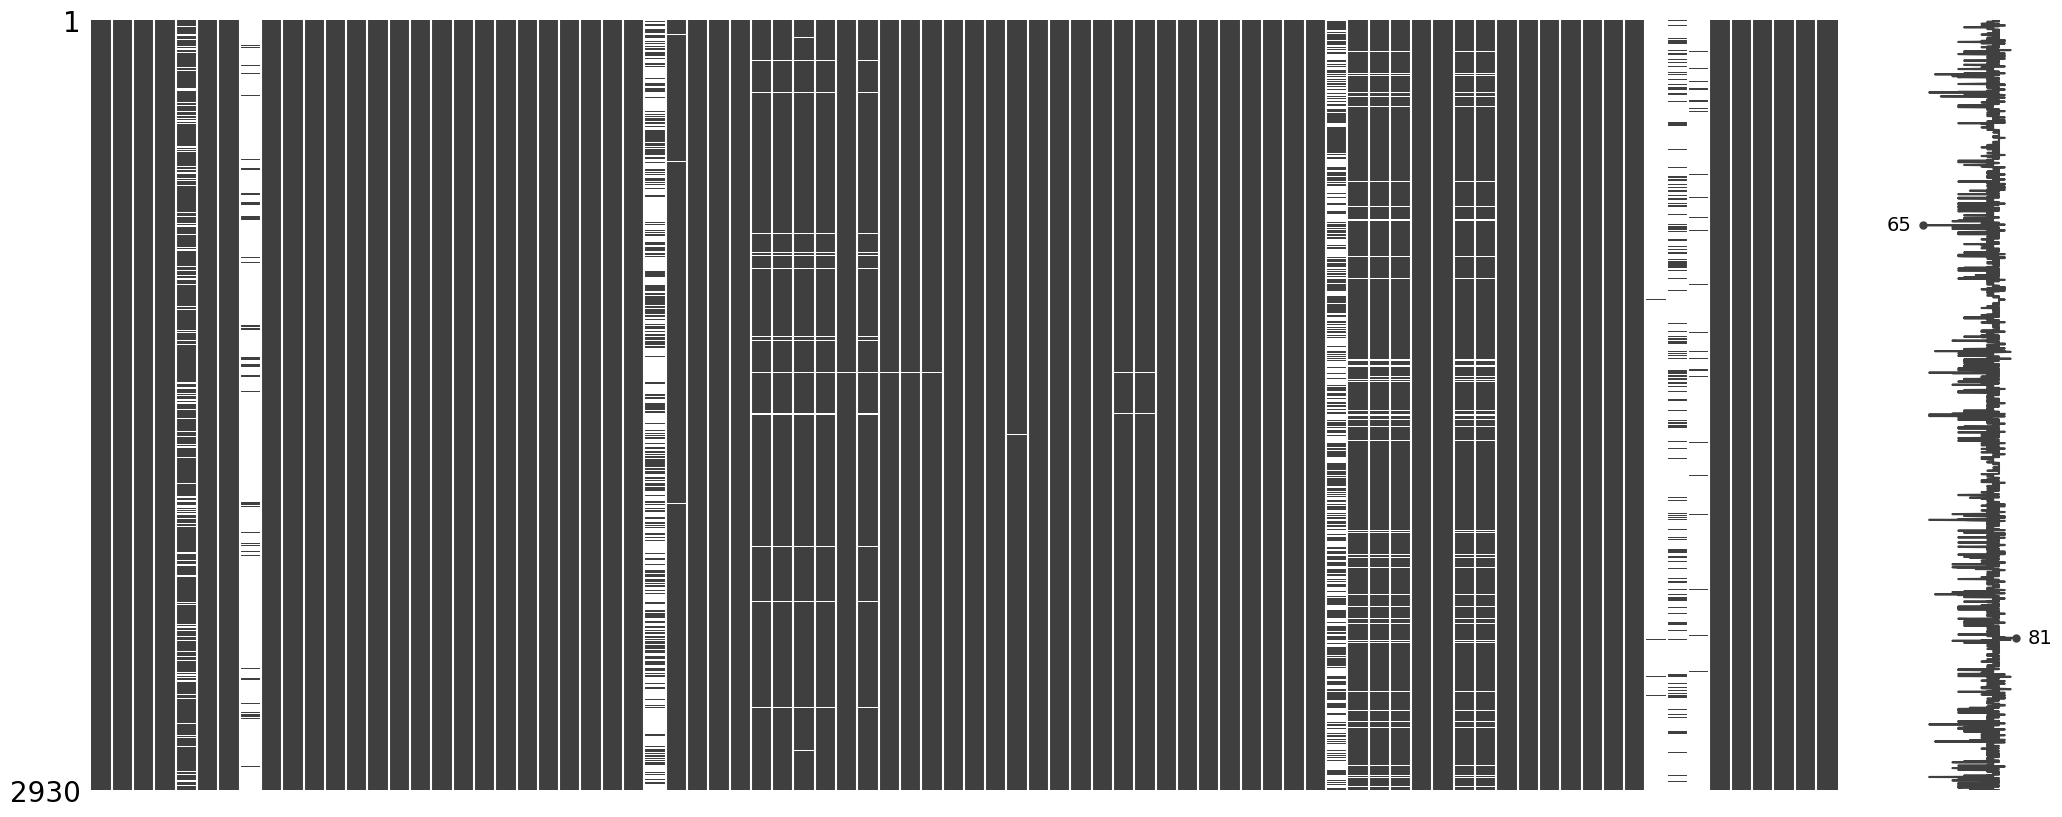

In [7]:
#Plot the missing data
import missingno as msno

msno.matrix(df)
plt.show()

### Target Variable: Housing Price

In [8]:
#Target Value; mean and standard deviation
sp_mean=df['SalePrice'].mean()
sp_sd=df['SalePrice'].std()

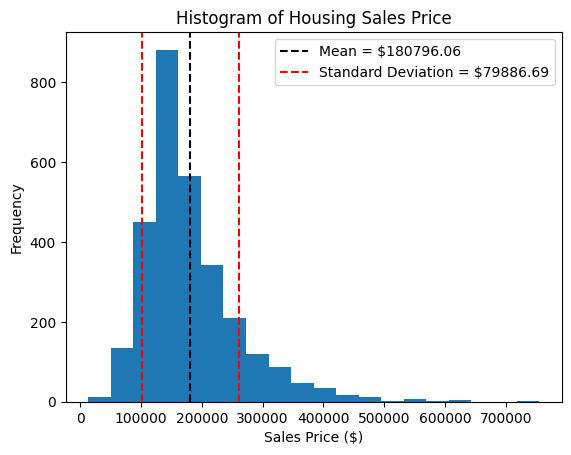

In [9]:
#histogram of target value (Sales Price)
plt.hist(df['SalePrice'],bins=20)
plt.axvline(sp_mean, color='black', linestyle='--', label=f'Mean = ${sp_mean:.2f}')
plt.axvline(sp_mean-sp_sd, color='red', linestyle='--', label=f'Standard Deviation = ${sp_sd:.2f}')
plt.axvline(sp_mean+sp_sd, color='red', linestyle='--')
plt.xlabel('Sales Price ($)')
plt.ylabel('Frequency')
plt.title('Histogram of Housing Sales Price')
plt.legend(loc='upper right')
plt.show()

#### Grouping: Percentile

In [10]:
#Percentiles
p20=df['SalePrice'].quantile(.2)
p40=df['SalePrice'].quantile(.4)
p60=df['SalePrice'].quantile(.6)
p80=df['SalePrice'].quantile(.8)
print(f'20th Percentile: {p20}')
print(f'40th Percentile: {p40}')
print(f'60th Percentile: {p60}')
print(f'80th Percentile: {p80}')

20th Percentile: 124000.0
40th Percentile: 146500.0
60th Percentile: 178535.99999999994
80th Percentile: 230000.0


In [11]:
#20% bins
df['Percentile Bins']=pd.qcut(df['SalePrice'],q=[0, 0.2, 0.4, 0.6, 0.8, 1],labels=['< $124,000','$124,000-$146,500','$146,500-$178,536','$178,536-$230,000','> $230,000'])
df.iloc[:,-2:]

,SalePrice,Percentile Bins
0,215000,"$178,536-$230,000"
1,105000,"< $124,000"
2,172000,"$146,500-$178,536"
3,244000,"> $230,000"
4,189900,"$178,536-$230,000"
...,...,...
2925,142500,"$124,000-$146,500"
2926,131000,"$124,000-$146,500"
2927,132000,"$124,000-$146,500"
2928,170000,"$146,500-$178,536"


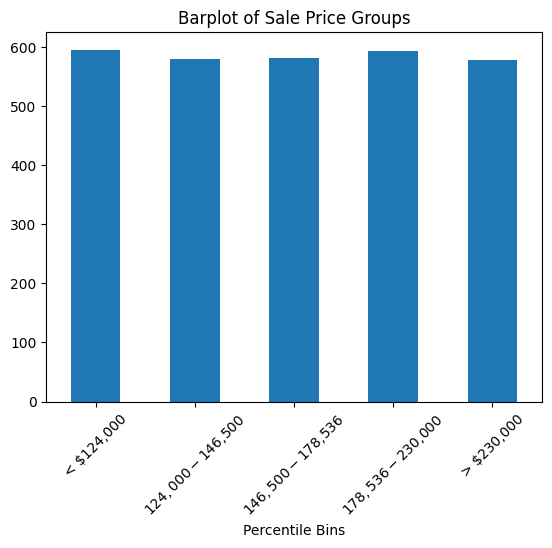

In [12]:
df['Percentile Bins'].value_counts().sort_index().plot(kind='bar')
plt.title('Barplot of Sale Price Groups')
plt.xticks(rotation=45)
plt.show()

#### Grouping: Distribution

In [13]:
bins=[0, 100000, 180000, 260000, 400000, np.inf]
df['Price Bins']=pd.cut(df['SalePrice'],bins=bins,labels=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k'],ordered=True)

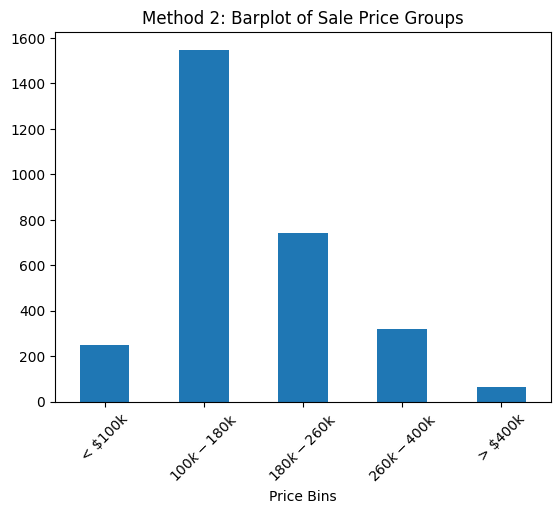

In [14]:
df['Price Bins'].value_counts().sort_index().plot(kind='bar')
plt.title('Method 2: Barplot of Sale Price Groups')
plt.xticks(rotation=45)
plt.show()

### Correlation

In [15]:
corr=df.corr(numeric_only=True)

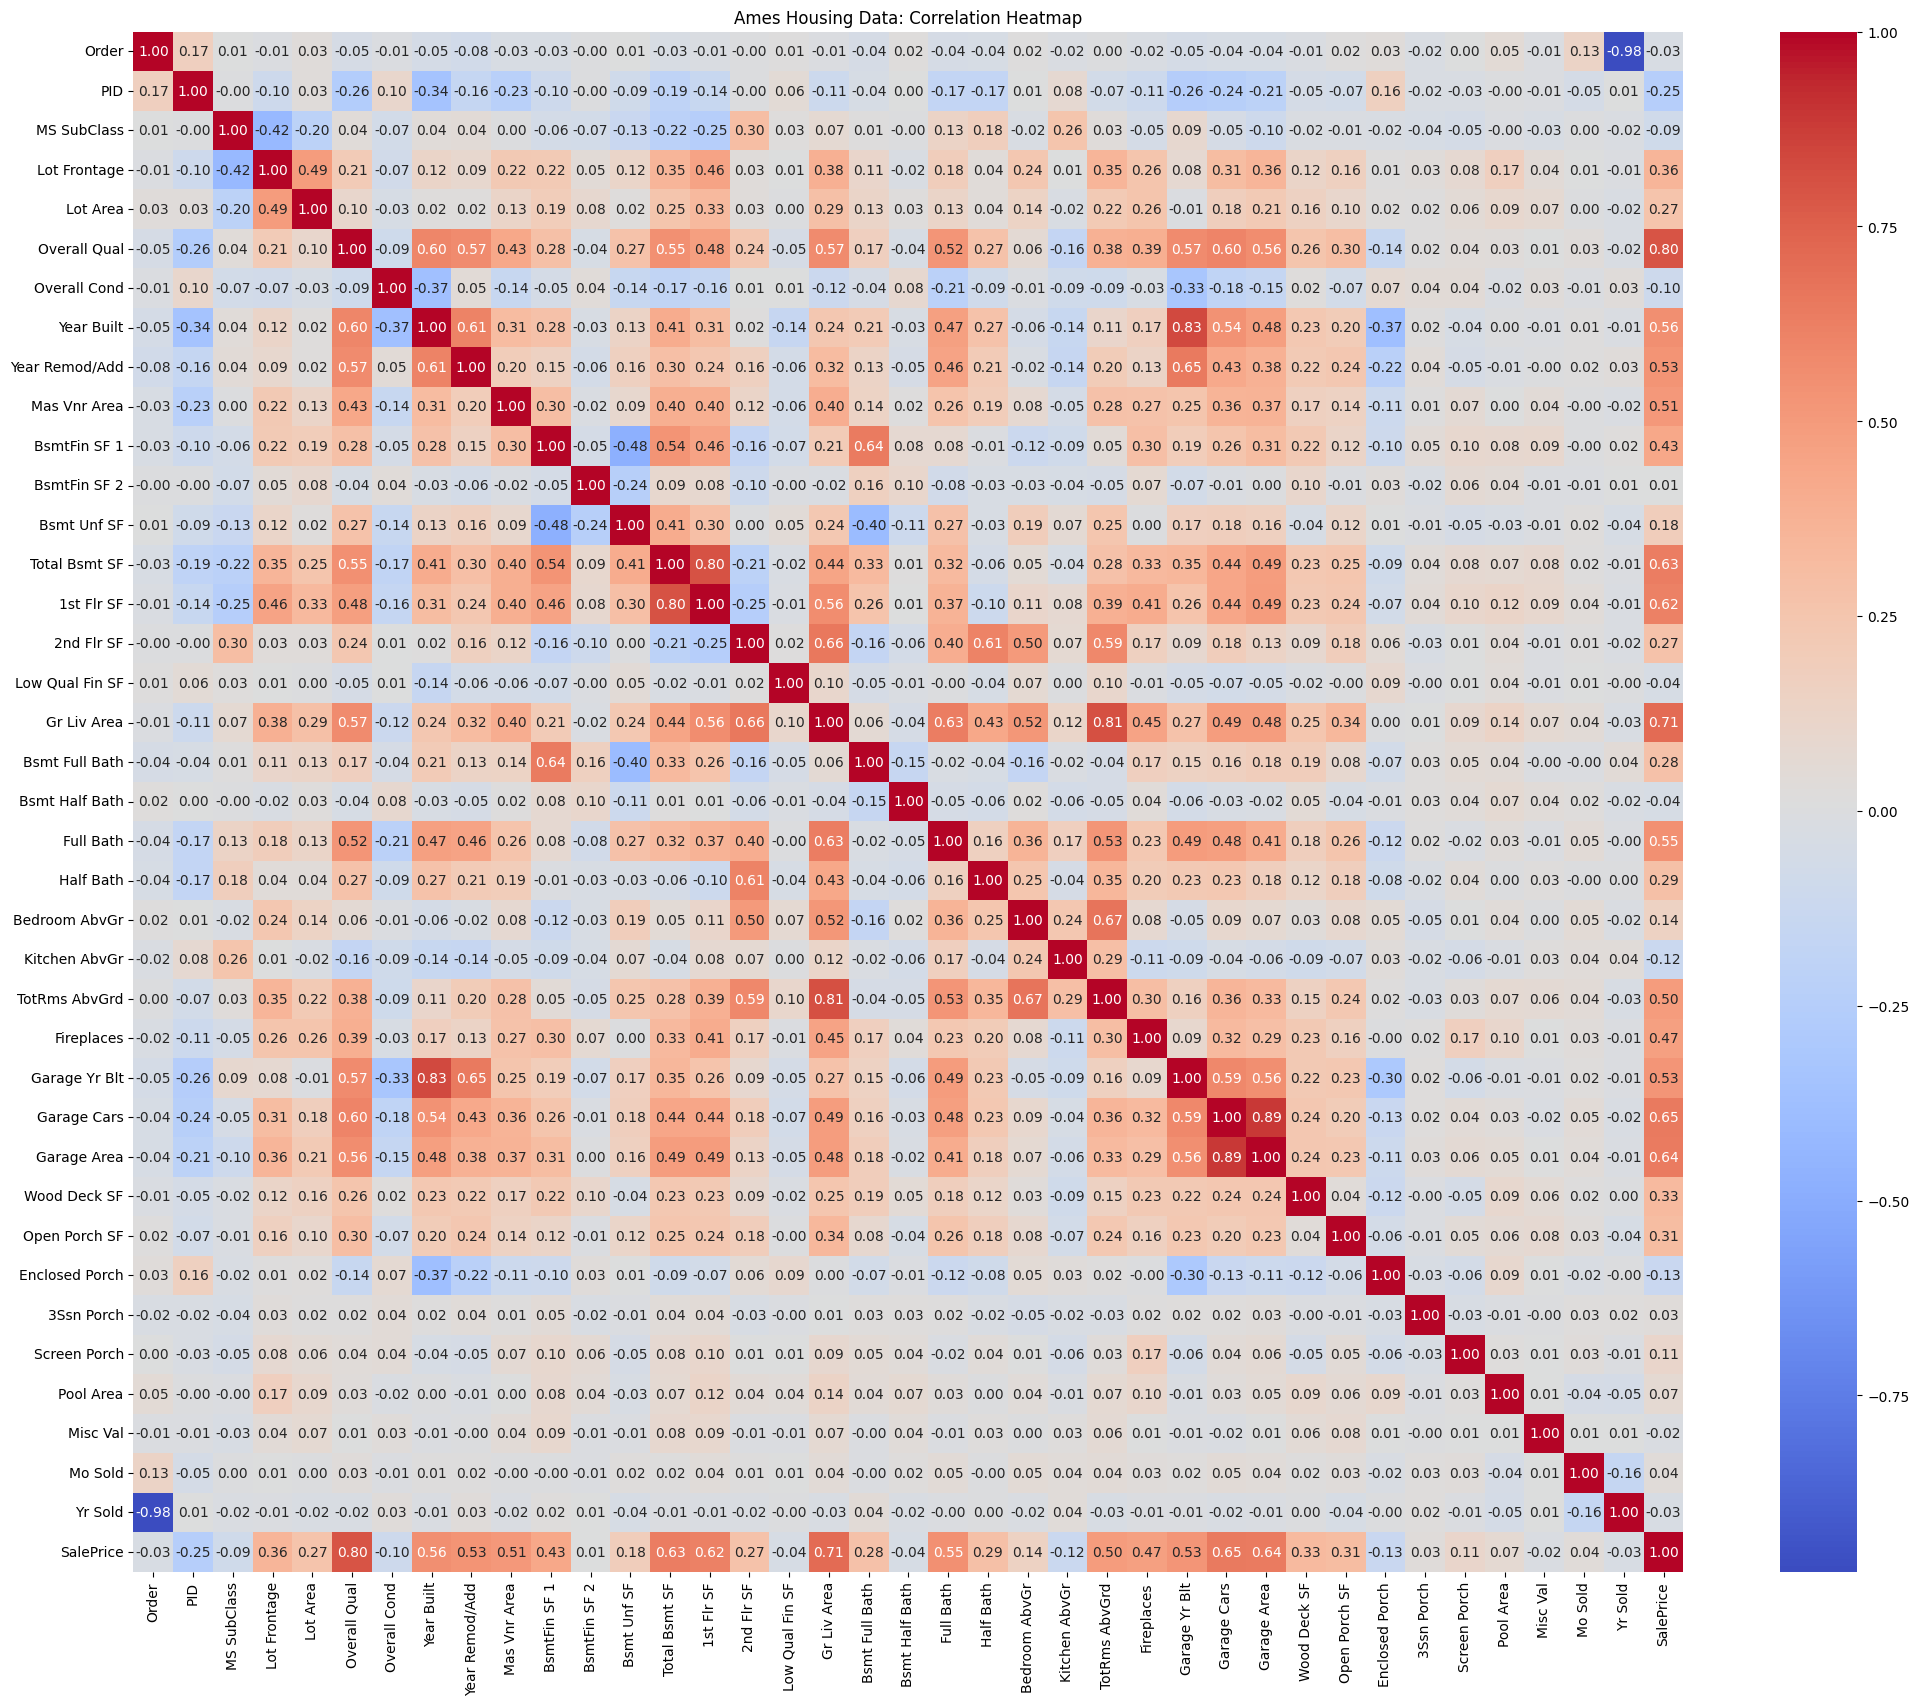

In [16]:
plt.figure(figsize=(25, 20))
sns.heatmap(corr,annot=True,fmt=".2f",cmap='coolwarm')
plt.title('Ames Housing Data: Correlation Heatmap')
plt.show()

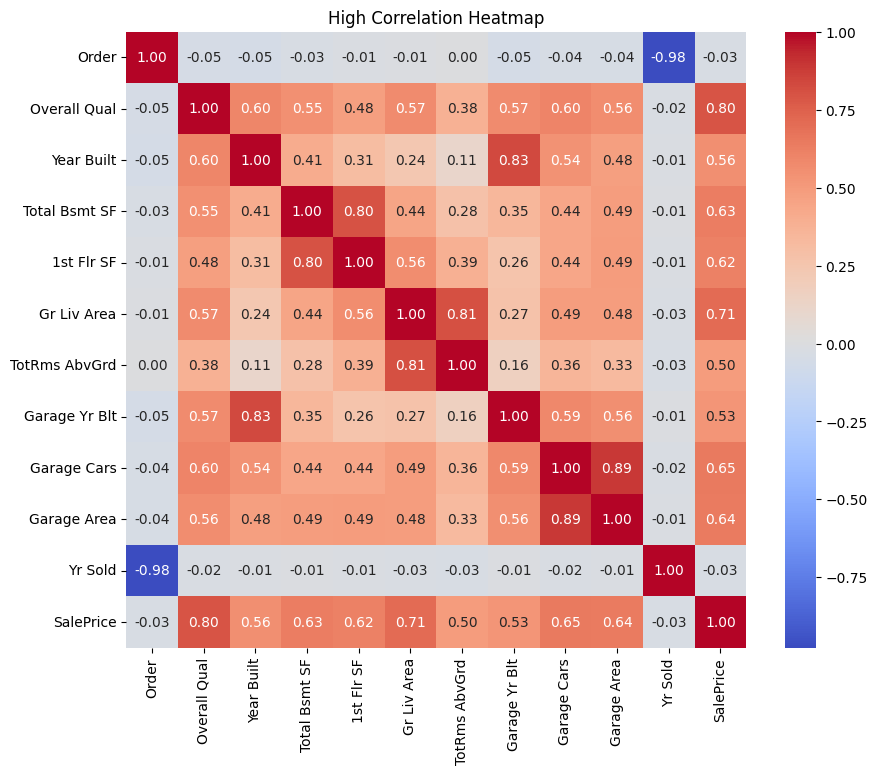

In [17]:
#correlation >= |0.7|
high_corr=(corr.abs()>0.7) & (corr!=1)
high_corr_cols=high_corr.any(axis=0)
filtered_corr=corr.loc[high_corr_cols,high_corr_cols]

#plot
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr,annot=True,fmt=".2f",cmap='coolwarm')
plt.title('High Correlation Heatmap')
plt.show()

### Investigations based on Feature Type
* Categorical Nominal
* Categorical Ordinal
* Numerical Discrete
* Numerical Continuous

In [18]:
#grouping columns
cat_nom=['MS SubClass','MS Zoning','Alley','Street','Land Contour','Lot Config','Neighborhood','Condition 1','Condition 2','Bldg Type','House Style','Roof Style','Roof Matl','Exterior 1st','Exterior 2nd','Mas Vnr Type','Foundation','Heating','Central Air','Garage Type','Misc Feature','Sale Type','Sale Condition']
cat_ord=['Lot Shape','Utilities','Land Slope','Overall Qual','Overall Cond','Exter Qual','Exter Cond','Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2','Heating QC','Electrical','Kitchen Qual','Functional','Fireplace Qu','Garage Finish','Garage Qual','Garage Cond','Paved Drive','Pool QC','Fence']
num_disc=['Year Built','Bsmt Full Bath','Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr','Kitchen AbvGr','TotRms AbvGrd','Fireplaces','Garage Yr Blt','Garage Cars','Mo Sold', 'Yr Sold']
num_cont=['Lot Frontage', 'Lot Area','Mas Vnr Area','BsmtFin SF 1','BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF','1st Flr SF','2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area','Garage Area','Wood Deck SF', 'Open Porch SF','Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area','Misc Val']

In [19]:
#table summary; outliers

#function to count outliers
def count_outliers(data):
    #setup for nice table output
    out_count=[]
    out_perc=[]

    #iterating through columns to find number of outliers
    for col in data.columns:
        outlier_count=0
        q1=data[col].quantile(0.25)
        q3=data[col].quantile(0.75)
        IQR=q3-q1
        lower=q1-(1.5*IQR)
        upper=q3+(1.5*IQR)
        for val in data[col]:
            if val<lower or val>upper:
                outlier_count+=1
        out_count.append(outlier_count)
        out_perc.append(outlier_count/len(data)*100)

    return out_count, out_perc

In [20]:
#function to create summary table (categorical)
def cat_table(data):
    cols=[]
    val_count=[]
    vals=[]
    na_count=[]
    na_perc=[]

    for col in data:
        cols.append(col)
        val_count.append(len(df[col].unique()))
        vals.append(data[col].unique().tolist())
        na_count.append(data[col].isnull().sum())
        na_perc.append(data[col].isnull().sum()/len(data)*100)

    sumtab={
        'Features':cols,
        '# of Unique Values':val_count,
        'Values':vals,
        'NA Count':na_count,
        'NA %':na_perc
        }
    sumtab=pd.DataFrame(sumtab)
    sumtab.set_index('Features',inplace=True)
    return sumtab

In [21]:
#function to create summary table (numerical)
def num_table(data):
    num_cols=[]
    val_count=[]
    val_range=[]
    na_count=[]
    na_perc=[]

    for col in data:
        num_cols.append(col)
        val_count.append(len(df[col].unique()))
        val_range.append(f'{data[col].min()} - {data[col].max()}')
        na_count.append(data[col].isnull().sum())
        na_perc.append(data[col].isnull().sum()/len(data)*100)

    out_count,out_perc=count_outliers(data)

    sumtab={
        'Features':num_cols,
        '# of Unique Values':val_count,
        'Range':val_range,
        'NA Count':na_count,
        'NA %':na_perc,
        'Outliers': out_count,
        'Outliers %': out_perc
        }

    sumtab=pd.DataFrame(sumtab)
    sumtab.set_index('Features',inplace=True)
    return sumtab

In [22]:
#Nominal Features; Summary table
nominal_table=cat_table(df[cat_nom])
nominal_table

,# of Unique Values,Values,NA Count,NA %
Features,,,,
MS SubClass,16,"[20, 60, 120, 50, 85, 160, 80, 30, 90, 190, 45...",0,0.000000
MS Zoning,7,"[RL, RH, FV, RM, C (all), I (all), A (agr)]",0,0.000000
Alley,3,"[nan, Pave, Grvl]",2732,93.242321
Street,2,"[Pave, Grvl]",0,0.000000
Land Contour,4,"[Lvl, HLS, Bnk, Low]",0,0.000000
Lot Config,5,"[Corner, Inside, CulDSac, FR2, FR3]",0,0.000000
Neighborhood,28,"[NAmes, Gilbert, StoneBr, NWAmes, Somerst, BrD...",0,0.000000
Condition 1,9,"[Norm, Feedr, PosN, RRNe, RRAe, Artery, PosA, ...",0,0.000000
Condition 2,8,"[Norm, Feedr, PosA, PosN, Artery, RRNn, RRAe, ...",0,0.000000


In [23]:
#Ordinal Features; Summary table
ordinal_table=cat_table(df[cat_ord])
ordinal_table

,# of Unique Values,Values,NA Count,NA %
Features,,,,
Lot Shape,4,"[IR1, Reg, IR2, IR3]",0,0.000000
Utilities,3,"[AllPub, NoSewr, NoSeWa]",0,0.000000
Land Slope,3,"[Gtl, Mod, Sev]",0,0.000000
Overall Qual,10,"[6, 5, 7, 8, 9, 4, 3, 2, 10, 1]",0,0.000000
Overall Cond,9,"[5, 6, 7, 2, 8, 4, 9, 3, 1]",0,0.000000
Exter Qual,4,"[TA, Gd, Ex, Fa]",0,0.000000
Exter Cond,5,"[TA, Gd, Fa, Po, Ex]",0,0.000000
Bsmt Qual,6,"[TA, Gd, Ex, nan, Fa, Po]",80,2.730375
Bsmt Cond,6,"[Gd, TA, nan, Po, Fa, Ex]",80,2.730375


In [24]:
#Discrete Features; Summary table
discrete_table=num_table(df[num_disc])
discrete_table

,# of Unique Values,Range,NA Count,NA %,Outliers,Outliers %
Features,,,,,,
Year Built,118,1872 - 2010,0,0.000000,9,0.307167
Bsmt Full Bath,5,0.0 - 3.0,2,0.068259,2,0.068259
Bsmt Half Bath,4,0.0 - 2.0,2,0.068259,175,5.972696
Full Bath,5,0 - 4,0,0.000000,4,0.136519
Half Bath,3,0 - 2,0,0.000000,0,0.000000
Bedroom AbvGr,8,0 - 8,0,0.000000,78,2.662116
Kitchen AbvGr,4,0 - 3,0,0.000000,134,4.573379
TotRms AbvGrd,14,2 - 15,0,0.000000,51,1.740614
Fireplaces,5,0 - 4,0,0.000000,13,0.443686


In [25]:
#Continous Features; Summary table
continuous_table=num_table(df[num_cont])
continuous_table

,# of Unique Values,Range,NA Count,NA %,Outliers,Outliers %
Features,,,,,,
Lot Frontage,129,21.0 - 313.0,490,16.723549,187,6.382253
Lot Area,1960,1300 - 215245,0,0.000000,127,4.334471
Mas Vnr Area,446,0.0 - 1600.0,23,0.784983,200,6.825939
BsmtFin SF 1,996,0.0 - 5644.0,1,0.034130,15,0.511945
BsmtFin SF 2,275,0.0 - 1526.0,1,0.034130,351,11.979522
Bsmt Unf SF,1138,0.0 - 2336.0,1,0.034130,56,1.911263
Total Bsmt SF,1059,0.0 - 6110.0,1,0.034130,123,4.197952
1st Flr SF,1083,334 - 5095,0,0.000000,43,1.467577
2nd Flr SF,635,0 - 2065,0,0.000000,8,0.273038


### Baseline Models
* Regression
* Classification
    * Percentile Grouping
    * Distribution Grouping

Using only numerical columns, no normalization or standardization

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, mean_absolute_error, mean_squared_error, r2_score

#### Preparing dataset for baseline

In [27]:
#dropping columns with high amounts of missing values
high_na=['Pool QC','Fence','Misc Feature','Alley','Mas Vnr Type','Fireplace Qu']
baseline=df.drop(columns=high_na)

In [28]:
#dropping identifying columns
baseline.drop(columns=['Order','PID'], inplace=True)
baseline

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Percentile Bins,Price Bins
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,5,2010,WD,Normal,215000,"$178,536-$230,000",$180k-$260k
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,120,0,0,6,2010,WD,Normal,105000,"< $124,000",$100k-$180k
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,12500,6,2010,WD,Normal,172000,"$146,500-$178,536",$100k-$180k
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,4,2010,WD,Normal,244000,"> $230,000",$180k-$260k
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,3,2010,WD,Normal,189900,"$178,536-$230,000",$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,3,2006,WD,Normal,142500,"$124,000-$146,500",$100k-$180k
2926,20,RL,NaN,8885,Pave,IR1,Low,AllPub,Inside,Mod,...,0,0,0,6,2006,WD,Normal,131000,"$124,000-$146,500",$100k-$180k
2927,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,700,7,2006,WD,Normal,132000,"$124,000-$146,500",$100k-$180k
2928,20,RL,77.0,10010,Pave,Reg,Lvl,AllPub,Inside,Mod,...,0,0,0,4,2006,WD,Normal,170000,"$146,500-$178,536",$100k-$180k


In [29]:
#columns that need encoding (categorical)
need_onehot=['MS SubClass','MS Zoning','Street','Land Contour','Lot Config','Neighborhood','Condition 1','Condition 2','Bldg Type','House Style','Roof Style','Roof Matl','Exterior 1st','Exterior 2nd','Foundation','Heating','Central Air','Garage Type','Sale Type','Sale Condition']
label_encoding=['Lot Shape','Utilities','Land Slope','Overall Qual','Overall Cond','Exter Qual','Exter Cond','Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2','Heating QC','Electrical','Kitchen Qual','Functional','Garage Finish','Garage Qual','Garage Cond','Paved Drive']


In [30]:
#numerical columns only + target variables
nums=baseline.drop(columns=need_onehot)
nums=nums.drop(columns=label_encoding)
nums

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Percentile Bins,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,0,0,0,0,0,5,2010,215000,"$178,536-$230,000",$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,0,0,120,0,0,6,2010,105000,"< $124,000",$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,0,0,0,0,12500,6,2010,172000,"$146,500-$178,536",$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,0,0,0,0,0,4,2010,244000,"> $230,000",$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,0,0,0,0,0,3,2010,189900,"$178,536-$230,000",$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,0,0,0,0,0,3,2006,142500,"$124,000-$146,500",$100k-$180k
2926,NaN,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,0,0,0,0,0,6,2006,131000,"$124,000-$146,500",$100k-$180k
2927,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,0,0,0,0,700,7,2006,132000,"$124,000-$146,500",$100k-$180k
2928,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,0,0,0,0,0,4,2006,170000,"$146,500-$178,536",$100k-$180k


In [31]:
nums=nums.dropna()
nums.isnull().sum()

Lot Frontage       0
Lot Area           0
Year Built         0
Year Remod/Add     0
Mas Vnr Area       0
BsmtFin SF 1       0
BsmtFin SF 2       0
Bsmt Unf SF        0
Total Bsmt SF      0
1st Flr SF         0
2nd Flr SF         0
Low Qual Fin SF    0
Gr Liv Area        0
Bsmt Full Bath     0
Bsmt Half Bath     0
Full Bath          0
Half Bath          0
Bedroom AbvGr      0
Kitchen AbvGr      0
TotRms AbvGrd      0
Fireplaces         0
Garage Yr Blt      0
Garage Cars        0
Garage Area        0
Wood Deck SF       0
Open Porch SF      0
Enclosed Porch     0
3Ssn Porch         0
Screen Porch       0
Pool Area          0
Misc Val           0
Mo Sold            0
Yr Sold            0
SalePrice          0
Percentile Bins    0
Price Bins         0
dtype: int64

#### Regression

In [32]:
cls_reg=LinearRegression()
nums.columns=nums.columns.astype(str)
X_reg = nums.iloc[:,:-3] #excluding both target var
y_reg = nums.iloc[:,-3] #only continuous target var
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=123)

cls_reg.fit(X_train_reg,y_train_reg)

mse=mean_squared_error(y_test_reg,cls_reg.predict(X_test_reg))
mae=mean_absolute_error(y_test_reg,cls_reg.predict(X_test_reg))
r2=r2_score(y_test_reg,cls_reg.predict(X_test_reg))

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-Squared: {r2}')

Mean Squared Error: 1630589464.057763
Mean Absolute Error: 24886.211702743694
R-Squared: 0.7823625738637483


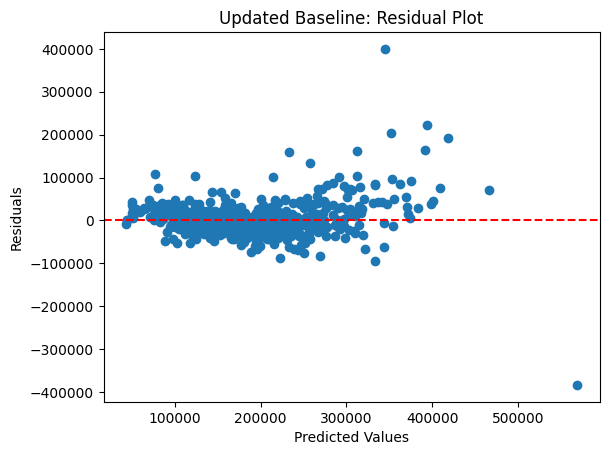

In [65]:
#residual plot
reg_y_pred=cls_reg.predict(X_test_reg)
residuals=y_test_reg.squeeze()-reg_y_pred

plt.scatter(reg_y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Updated Baseline: Residual Plot')
plt.show()

#### Classification: Decision Tree

In [34]:
cls=DecisionTreeClassifier()
nums.columns=nums.columns.astype(str)
X = nums.iloc[:,:-3] #excluding both target var
y = nums.iloc[:,-1:] #only categorical target var (distribution method)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

cls.fit(X_train,y_train)

acc=accuracy_score(y_test,cls.predict(X_test))
prec=precision_score(y_test,cls.predict(X_test),average='macro')
recall=recall_score(y_test,cls.predict(X_test),average='macro')
f1_macro=f1_score(y_test,cls.predict(X_test),average='macro')

print(f'Accuracy: {acc}')
print(f'Precision (macro): {prec}')
print(f'Recall (macro): {recall}')
print(f'F1 (macro): {f1_macro}')

Accuracy: 0.7320644216691069
Precision (macro): 0.6515520594325828
Recall (macro): 0.6413958549403936
F1 (macro): 0.6461933824828312


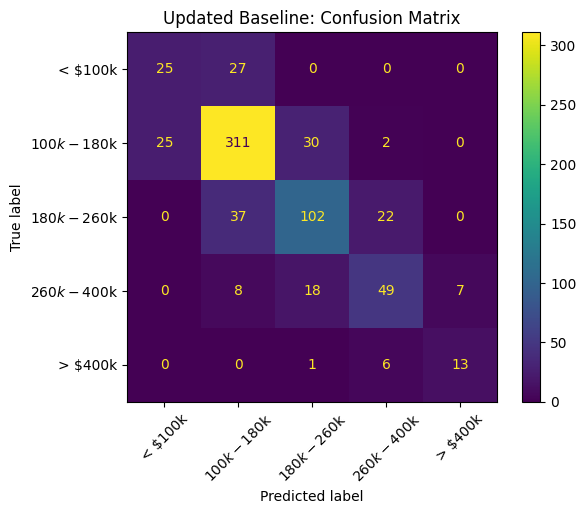

In [66]:
#Confusion Matrix
labels=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']
confusion=confusion_matrix(y_test,cls.predict(X_test),labels=labels)
confusion_mat=ConfusionMatrixDisplay(confusion,display_labels=labels)
confusion_mat.plot()
plt.title(f'Updated Baseline: Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

### Missing Values

In [36]:
#missing values; only columns with missing values
df.isnull().sum()[df.isnull().sum()>0]

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

#### Basement columns
Ordinal
* Bsmt Qual
* Bsmt Cond
* Bsmt Exposure
* BsmtFin Type 1
* BsmtFin Type 2

Discrete
* Bsmt Full Bath
* Bsmt Half Bath

Continuous
* BsmtFin SF 1
* BsmtFin SF 2
* Bsmt Unf SF
* Total Bsmt SF

In [37]:
#basement columns only
basement_cols=['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2','Bsmt Full Bath','Bsmt Half Bath','BsmtFin SF 1','BsmtFin SF 2','Bsmt Unf SF','Total Bsmt SF']
basement=df[basement_cols]
basement

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Bsmt Full Bath,Bsmt Half Bath,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF
0,TA,Gd,Gd,BLQ,Unf,1.0,0.0,639.0,0.0,441.0,1080.0
1,TA,TA,No,Rec,LwQ,0.0,0.0,468.0,144.0,270.0,882.0
2,TA,TA,No,ALQ,Unf,0.0,0.0,923.0,0.0,406.0,1329.0
3,TA,TA,No,ALQ,Unf,1.0,0.0,1065.0,0.0,1045.0,2110.0
4,Gd,TA,No,GLQ,Unf,0.0,0.0,791.0,0.0,137.0,928.0
...,...,...,...,...,...,...,...,...,...,...,...
2925,TA,TA,Av,GLQ,Unf,1.0,0.0,819.0,0.0,184.0,1003.0
2926,Gd,TA,Av,BLQ,ALQ,1.0,0.0,301.0,324.0,239.0,864.0
2927,Gd,TA,Av,GLQ,Unf,0.0,1.0,337.0,0.0,575.0,912.0
2928,Gd,TA,Av,ALQ,LwQ,1.0,0.0,1071.0,123.0,195.0,1389.0


In [38]:
basement.isnull().sum()

Bsmt Qual         80
Bsmt Cond         80
Bsmt Exposure     83
BsmtFin Type 1    80
BsmtFin Type 2    81
Bsmt Full Bath     2
Bsmt Half Bath     2
BsmtFin SF 1       1
BsmtFin SF 2       1
Bsmt Unf SF        1
Total Bsmt SF      1
dtype: int64

In [39]:
#rows where ordinal (categorial) values are all null
basement_cat=['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2']
basement_catna=basement[basement[basement_cat].isnull().all(axis=1)]
basement_catna

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Bsmt Full Bath,Bsmt Half Bath,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF
83,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
154,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
206,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
243,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
273,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2739,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2744,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2879,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2892,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
#filling missing values when logic says there is no basement
all_catna=basement[basement_cat].isnull().all(axis=1)
basement.loc[all_catna, basement_cat] = basement.loc[all_catna, basement_cat].fillna({
    'Bsmt Qual': 'No Basement',
    'Bsmt Cond': 'No Basement',
    'Bsmt Exposure': 'No Basement',
    'BsmtFin Type 1': 'No Basement',
    'BsmtFin Type 2': 'No Basement'
})
basement.isnull().sum()


Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     3
BsmtFin Type 1    0
BsmtFin Type 2    1
Bsmt Full Bath    2
Bsmt Half Bath    2
BsmtFin SF 1      1
BsmtFin SF 2      1
Bsmt Unf SF       1
Total Bsmt SF     1
dtype: int64

#### Fireplace Columns
* Fireplaces
* Fireplace Qu

In [41]:
fire_cols=['Fireplaces','Fireplace Qu']
fire=df[fire_cols]
fire

,Fireplaces,Fireplace Qu
0,2,Gd
1,0,NaN
2,0,NaN
3,2,TA
4,1,TA
...,...,...
2925,0,NaN
2926,0,NaN
2927,0,NaN
2928,1,TA


In [42]:
fire.isnull().sum()

Fireplaces         0
Fireplace Qu    1422
dtype: int64

In [43]:
firena=fire[(fire['Fireplace Qu'].isnull()) & (fire['Fireplaces']==0)]
firena

,Fireplaces,Fireplace Qu
1,0,NaN
2,0,NaN
6,0,NaN
7,0,NaN
11,0,NaN
...,...,...
2921,0,NaN
2922,0,NaN
2925,0,NaN
2926,0,NaN


In [44]:
#filling missing values when logic says there is no fireplace
fire.loc[(fire['Fireplace Qu'].isnull()) & (fire['Fireplaces']==0),'Fireplace Qu'] = fire.loc[(fire['Fireplace Qu'].isnull()) & (fire['Fireplaces']==0),'Fireplace Qu'].fillna('No Fireplace')
fire.isnull().sum()

Fireplaces      0
Fireplace Qu    0
dtype: int64

#### Garage Columns
Nominal
* Garage Type

Ordinal
* Garage Finish
* Garage Qual
* Garage Cond

Discrete
* Garage Yr Blt

Continuous
* Garage Area

In [45]:
garage_cols=['Garage Type','Garage Finish','Garage Qual','Garage Cond','Garage Yr Blt','Garage Cars','Garage Area']
garage=df[garage_cols]
garage

,Garage Type,Garage Finish,Garage Qual,Garage Cond,Garage Yr Blt,Garage Cars,Garage Area
0,Attchd,Fin,TA,TA,1960.0,2.0,528.0
1,Attchd,Unf,TA,TA,1961.0,1.0,730.0
2,Attchd,Unf,TA,TA,1958.0,1.0,312.0
3,Attchd,Fin,TA,TA,1968.0,2.0,522.0
4,Attchd,Fin,TA,TA,1997.0,2.0,482.0
...,...,...,...,...,...,...,...
2925,Detchd,Unf,TA,TA,1984.0,2.0,588.0
2926,Attchd,Unf,TA,TA,1983.0,2.0,484.0
2927,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2928,Attchd,RFn,TA,TA,1975.0,2.0,418.0


In [46]:
garage.isnull().sum()

Garage Type      157
Garage Finish    159
Garage Qual      159
Garage Cond      159
Garage Yr Blt    159
Garage Cars        1
Garage Area        1
dtype: int64

In [47]:
gar_nacols=['Garage Type','Garage Finish','Garage Qual','Garage Cond','Garage Yr Blt','Garage Yr Blt']
garagena=garage[(garage[gar_nacols].isnull().all(axis=1)) & (garage['Garage Area']==0)]
garagena

,Garage Type,Garage Finish,Garage Qual,Garage Cond,Garage Yr Blt,Garage Cars,Garage Area
27,NaN,NaN,NaN,NaN,NaN,0.0,0.0
119,NaN,NaN,NaN,NaN,NaN,0.0,0.0
125,NaN,NaN,NaN,NaN,NaN,0.0,0.0
129,NaN,NaN,NaN,NaN,NaN,0.0,0.0
130,NaN,NaN,NaN,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...
2913,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2916,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2918,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2919,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [48]:
#filling categorial columns
gar_cat=['Garage Type','Garage Finish','Garage Qual','Garage Cond']
gar_catna=garage[gar_cat].isnull().all(axis=1)
garage.loc[gar_catna, gar_cat] = garage.loc[gar_catna, gar_cat].fillna({
    'Garage Type': 'No Garage',
    'Garage Finish': 'No Garage',
    'Garage Qual': 'No Garage',
    'Garage Cond': 'No Garage'
})
garage.isnull().sum()

Garage Type        0
Garage Finish      2
Garage Qual        2
Garage Cond        2
Garage Yr Blt    159
Garage Cars        1
Garage Area        1
dtype: int64

#### Masonry Columns
* Mas Vnr Type
* Mas Vnr Area

In [49]:
mas_cols=['Mas Vnr Type','Mas Vnr Area']
mas=df[mas_cols]
mas

,Mas Vnr Type,Mas Vnr Area
0,Stone,112.0
1,NaN,0.0
2,BrkFace,108.0
3,NaN,0.0
4,NaN,0.0
...,...,...
2925,NaN,0.0
2926,NaN,0.0
2927,NaN,0.0
2928,NaN,0.0


In [50]:
masna=mas[(mas['Mas Vnr Type'].isnull()) & (mas['Mas Vnr Area']==0)]
masna

,Mas Vnr Type,Mas Vnr Area
1,NaN,0.0
3,NaN,0.0
4,NaN,0.0
6,NaN,0.0
7,NaN,0.0
...,...,...
2924,NaN,0.0
2925,NaN,0.0
2926,NaN,0.0
2927,NaN,0.0


In [51]:
#filling missing values when logic says there is no masonry
mas.loc[(mas['Mas Vnr Type'].isnull()) & (mas['Mas Vnr Area']==0),'Mas Vnr Type'] = mas.loc[(mas['Mas Vnr Type'].isnull()) & (mas['Mas Vnr Area']==0),'Mas Vnr Type'].fillna('No Masonry')
mas.isnull().sum()

Mas Vnr Type    30
Mas Vnr Area    23
dtype: int64

#### Pool Columns
* Pool QC
* Pool Area

In [52]:
pool_cols=['Pool QC','Pool Area']
pool=df[pool_cols]
poolna=pool[(pool['Pool QC'].isnull()) & (pool['Pool Area']==0)]
poolna

,Pool QC,Pool Area
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0
...,...,...
2925,NaN,0
2926,NaN,0
2927,NaN,0
2928,NaN,0


In [53]:
#filling missing values when logic says there is no pool
pool.loc[(pool['Pool QC'].isnull()) & (pool['Pool Area']==0),'Pool QC'] = pool.loc[(pool['Pool QC'].isnull()) & (pool['Pool Area']==0),'Pool QC'].fillna('No Pool')
pool.isnull().sum()

Pool QC      0
Pool Area    0
dtype: int64

#### Alley/Fence/Misc Features
* No other column to verify, but logically if no value then no alley/fence/misc features

#### Applying to DataFrame

In [54]:
#Basement Columns
basement_cat=['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2']
all_catna=df[basement_cat].isnull().all(axis=1)
df.loc[all_catna, basement_cat] = df.loc[all_catna, basement_cat].fillna({
    'Bsmt Qual': 'No Basement',
    'Bsmt Cond': 'No Basement',
    'Bsmt Exposure': 'No Basement',
    'BsmtFin Type 1': 'No Basement',
    'BsmtFin Type 2': 'No Basement'
})

In [55]:
#Fireplace columns
df.loc[(df['Fireplace Qu'].isnull()) & (df['Fireplaces']==0),'Fireplace Qu'] = df.loc[(df['Fireplace Qu'].isnull()) & (df['Fireplaces']==0),'Fireplace Qu'].fillna('No Fireplace')

In [56]:
#Garage columns
gar_cat=['Garage Type','Garage Finish','Garage Qual','Garage Cond']
gar_col=['Garage Type','Garage Finish','Garage Qual','Garage Cond','Garage Yr Blt']
gar_catna=df[gar_col].isnull().all(axis=1)
df.loc[gar_catna, gar_col] = df.loc[gar_catna, gar_col].fillna({
    'Garage Type': 'No Garage',
    'Garage Finish': 'No Garage',
    'Garage Qual': 'No Garage',
    'Garage Cond': 'No Garage'
})

df.loc[gar_catna, 'Garage Yr Blt']=0

In [57]:
#Masonry columns
df.loc[(df['Mas Vnr Type'].isnull()) & (df['Mas Vnr Area']==0),'Mas Vnr Type'] = df.loc[(df['Mas Vnr Type'].isnull()) & (df['Mas Vnr Area']==0),'Mas Vnr Type'].fillna('No Masonry')

In [58]:
#Pool columns
df.loc[(df['Pool QC'].isnull()) & (df['Pool Area']==0),'Pool QC'] = df.loc[(df['Pool QC'].isnull()) & (df['Pool Area']==0),'Pool QC'].fillna('No Pool')

In [59]:
#Alley/Fence/Misc Feature
df['Alley']=df['Alley'].fillna('No Alley Access')
df['Fence']=df['Fence'].fillna('No Fence')
df['Misc Feature']=df['Misc Feature'].fillna('No Misc Feature')

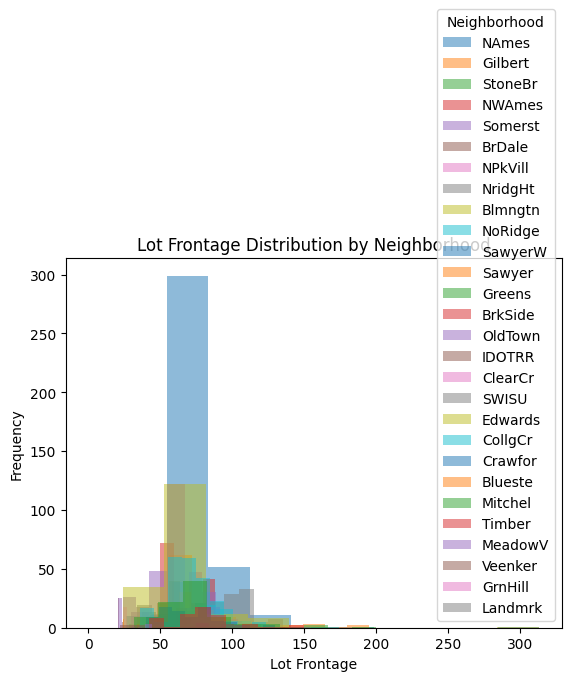

In [60]:
#Lot Frontage
for val in df['Neighborhood'].unique():
    group=df[df['Neighborhood']==val]
    group=group.dropna(subset=['Lot Frontage'])
    plt.hist(group['Lot Frontage'], alpha=0.5, label=val)

plt.legend(title='Neighborhood')
plt.title('Lot Frontage Distribution by Neighborhood')
plt.xlabel('Lot Frontage')
plt.ylabel('Frequency')
plt.show()

In [61]:
#Lot Frontage; filling missing values with Neighborhood Median
df['Lot Frontage']=df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

/Users/Temp/Data4380/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/Temp/Data4380/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [62]:
#missing values; only columns with missing values
df.isnull().sum()[df.isnull().sum()>0]

Lot Frontage       3
Mas Vnr Type      30
Mas Vnr Area      23
Bsmt Exposure      3
BsmtFin SF 1       1
BsmtFin Type 2     1
BsmtFin SF 2       1
Bsmt Unf SF        1
Total Bsmt SF      1
Electrical         1
Bsmt Full Bath     2
Bsmt Half Bath     2
Garage Yr Blt      2
Garage Finish      2
Garage Cars        1
Garage Area        1
Garage Qual        2
Garage Cond        2
dtype: int64

In [63]:
#remove identifying columns
df.drop(columns=['Order','PID'], inplace=True)
df

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Percentile Bins,Price Bins
0,20,RL,141.0,31770,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,No Fence,No Misc Feature,0,5,2010,WD,Normal,215000,"$178,536-$230,000",$180k-$260k
1,20,RH,80.0,11622,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,MnPrv,No Misc Feature,0,6,2010,WD,Normal,105000,"< $124,000",$100k-$180k
2,20,RL,81.0,14267,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,No Fence,Gar2,12500,6,2010,WD,Normal,172000,"$146,500-$178,536",$100k-$180k
3,20,RL,93.0,11160,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,No Fence,No Misc Feature,0,4,2010,WD,Normal,244000,"> $230,000",$180k-$260k
4,60,RL,74.0,13830,Pave,No Alley Access,IR1,Lvl,AllPub,Inside,...,MnPrv,No Misc Feature,0,3,2010,WD,Normal,189900,"$178,536-$230,000",$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,No Alley Access,IR1,Lvl,AllPub,CulDSac,...,GdPrv,No Misc Feature,0,3,2006,WD,Normal,142500,"$124,000-$146,500",$100k-$180k
2926,20,RL,74.0,8885,Pave,No Alley Access,IR1,Low,AllPub,Inside,...,MnPrv,No Misc Feature,0,6,2006,WD,Normal,131000,"$124,000-$146,500",$100k-$180k
2927,85,RL,62.0,10441,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,MnPrv,Shed,700,7,2006,WD,Normal,132000,"$124,000-$146,500",$100k-$180k
2928,20,RL,77.0,10010,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,No Fence,No Misc Feature,0,4,2006,WD,Normal,170000,"$146,500-$178,536",$100k-$180k


### Exporting dataframe as csv

In [64]:
#creating csv
df.to_csv("AmesHousing Cap1 Preprocessing.csv")